# Consumo de Água no Brasil

Análise exploratória de uma base **simulada** de 2015 a 2024. O objetivo é descrever padrões de consumo, perdas, chuva e reservatórios nos registros fornecidos.


## Base e método

Cada linha é um registro associado a data, região, UF e setor. A fonte não documenta uma unidade territorial menor nem garante uma observação única por UF e mês. Os totais apresentados são somas da amostra, não estimativas oficiais.


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))
from data import DATA_PATH, load_data, monthly_series, rain_correlation

raw = pd.read_csv(DATA_PATH)
df = load_data()
print(f'Registros originais: {len(raw):,} | válidos após preparo: {len(df):,}')
display(df.head())


Registros originais: 4,440 | válidos após preparo: 4,440


,ano,mes,data,regiao,uf,setor_consumo,consumo_milhoes_litros,desperdicio_percentual,reservatorios_percentual,chuva_mm,temperatura_media,populacao,consumo_per_capita,nivel_alerta
0,2015,1,2015-01-01,Centro-Oeste,DF,Agrícola,35.98,22.65,64.61,101.4,22.1,3881917,166.73,Médio
1,2015,1,2015-01-01,Centro-Oeste,GO,Público,35.19,17.55,42.62,67.8,28.2,5089834,123.68,Baixo
2,2015,1,2015-01-01,Centro-Oeste,GO,Industrial,32.37,24.10,12.60,140.2,25.2,2073082,96.69,Crítico
3,2015,1,2015-01-01,Centro-Oeste,MS,Industrial,3.81,36.34,52.66,81.4,29.5,400968,347.37,Crítico
4,2015,1,2015-01-01,Centro-Oeste,MT,Industrial,10.53,14.76,84.46,162.4,22.9,3522216,178.72,Baixo


## Limpeza e engenharia de atributos

A preparação converte datas e números, remove linhas incompletas, duplicatas exatas, datas incoerentes e valores fora dos limites para consumo, desperdício e reservatórios. A série mensal e a média móvel de 12 meses são atributos derivados.


In [2]:
display(pd.DataFrame({'ausentes': raw.isna().sum(), 'tipo_original': raw.dtypes.astype(str)}))
print(f'Linhas removidas no preparo: {len(raw) - len(df)}')
print(f'Período: {df.data.min():%m/%Y} a {df.data.max():%m/%Y}')
print(f'UFs: {df.uf.nunique()} | regiões: {df.regiao.nunique()} | setores: {df.setor_consumo.nunique()}')


,ausentes,tipo_original
ano,0,int64
mes,0,int64
data,0,str
regiao,0,str
uf,0,str
setor_consumo,0,str
consumo_milhoes_litros,0,float64
desperdicio_percentual,0,float64
reservatorios_percentual,0,float64
chuva_mm,0,float64


Linhas removidas no preparo: 0
Período: 01/2015 a 12/2024
UFs: 20 | regiões: 5 | setores: 5


## Indicadores principais

As médias usam os valores informados por registro. O consumo per capita fornecido não é recalculado porque a granularidade da coluna de população não foi documentada.


In [3]:
state_totals = df.groupby('uf').consumo_milhoes_litros.sum().sort_values(ascending=False)
sector_totals = df.groupby('setor_consumo').consumo_milhoes_litros.sum().sort_values(ascending=False)
kpis = pd.Series({
    'Consumo total (milhões L)': df.consumo_milhoes_litros.sum(),
    'Estado com maior soma': state_totals.index[0],
    'Setor com maior soma': sector_totals.index[0],
    'Consumo per capita médio': df.consumo_per_capita.mean(),
    'Desperdício médio (%)': df.desperdicio_percentual.mean(),
    'Reservatórios médios (%)': df.reservatorios_percentual.mean(),
})
display(kpis.to_frame('valor'))


,valor
Consumo total (milhões L),92566.21
Estado com maior soma,RJ
Setor com maior soma,Agrícola
Consumo per capita médio,266.515653
Desperdício médio (%),30.193739
Reservatórios médios (%),52.168302


## Evolução temporal e sazonalidade

A média móvel reduz oscilações mês a mês. O mapa de calor permite verificar se determinados meses se repetem com valores altos ou baixos ao longo dos anos.


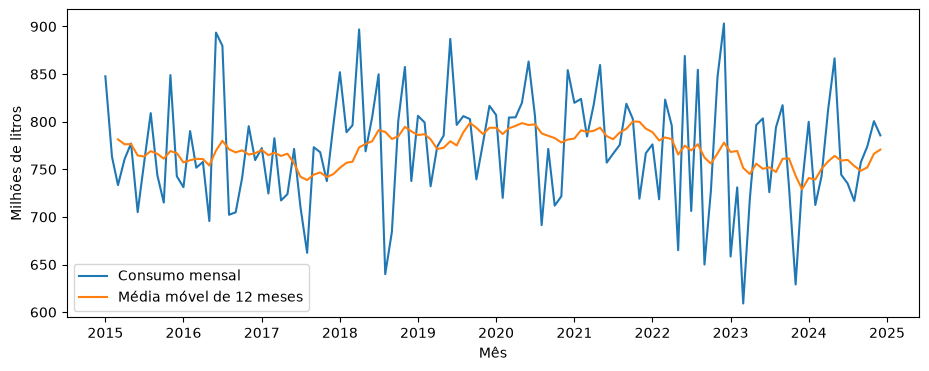

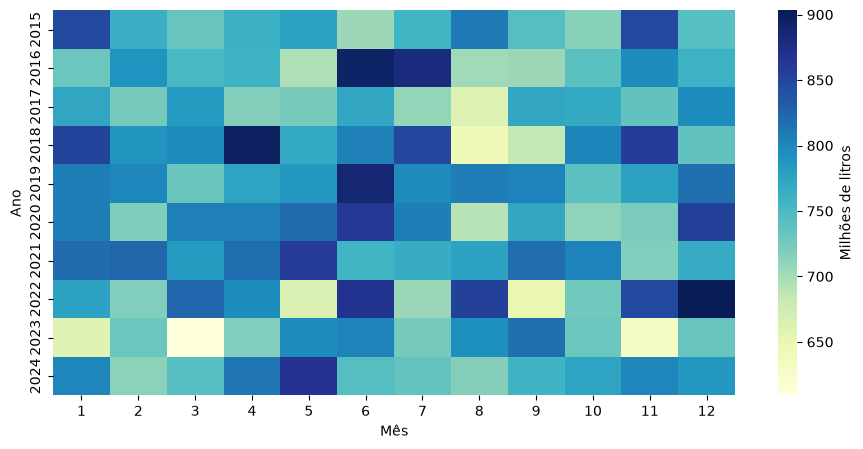

In [4]:
monthly = monthly_series(df)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.data, monthly.consumo_milhoes_litros, label='Consumo mensal')
ax.plot(monthly.data, monthly.media_movel_12m, label='Média móvel de 12 meses')
ax.set(ylabel='Milhões de litros', xlabel='Mês')
ax.legend()
plt.show()
heat = df.groupby(['ano', 'mes']).consumo_milhoes_litros.sum().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Milhões de litros'})
ax.set(xlabel='Mês', ylabel='Ano')
plt.show()


## Comparação por estado, região e setor

Esses rankings somam registros. Como há quantidades diferentes de linhas por UF, a comparação não deve ser lida como consumo real de cada estado.


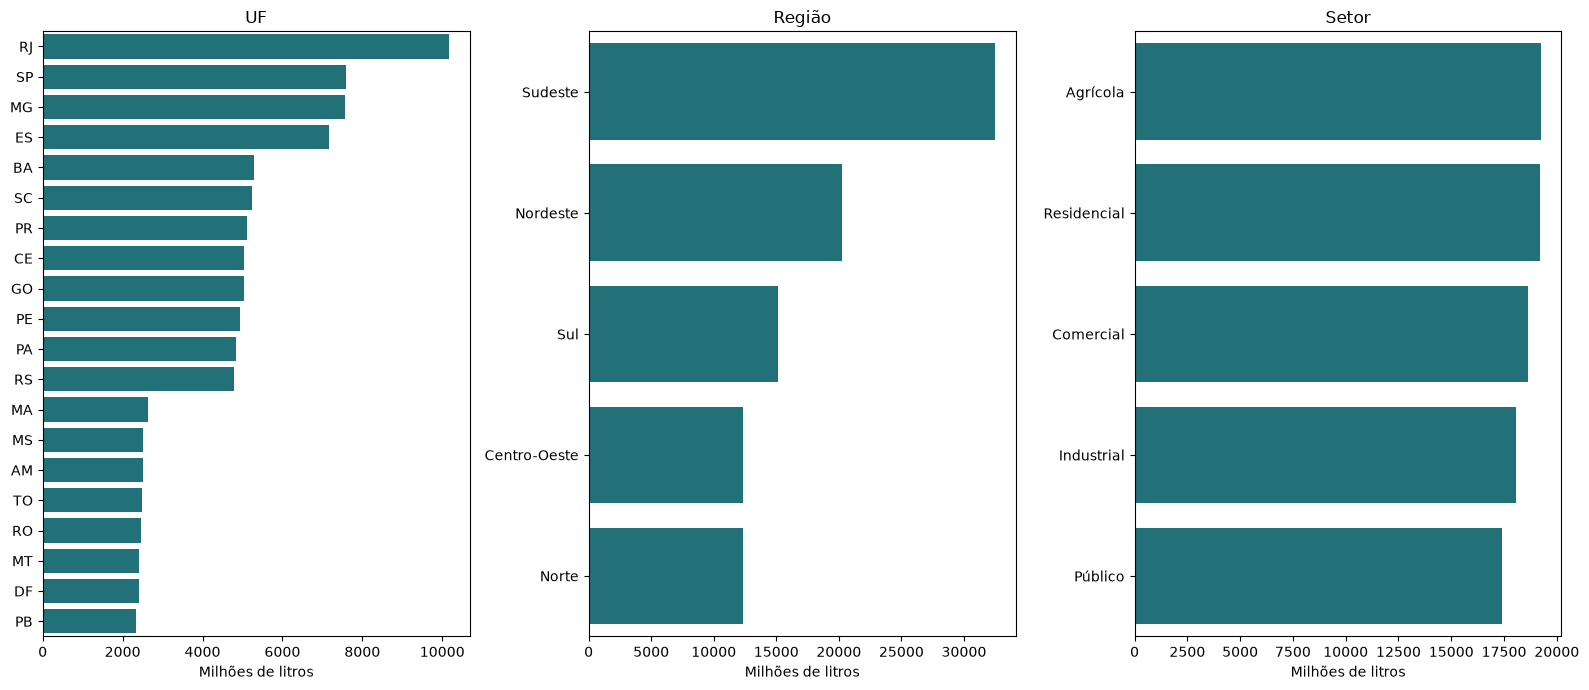

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, column, title in zip(axes, ['uf', 'regiao', 'setor_consumo'], ['UF', 'Região', 'Setor']):
    totals = df.groupby(column, as_index=False).consumo_milhoes_litros.sum().sort_values('consumo_milhoes_litros', ascending=False)
    sns.barplot(data=totals, y=column, x='consumo_milhoes_litros', ax=ax, color='#147d87')
    ax.set(title=title, xlabel='Milhões de litros', ylabel='')
fig.tight_layout()
plt.show()


## Chuva, desperdício e reservatórios

A correlação de Pearson resume uma associação linear entre a média de chuva e a soma de consumo por mês. Ela não indica causa nem mede risco real de escassez.


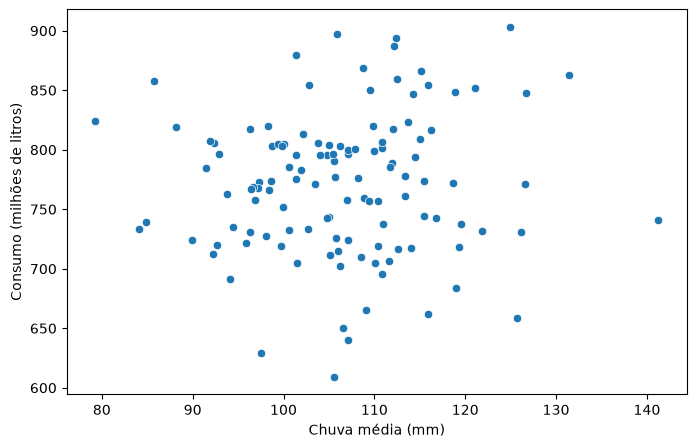

Correlação chuva × consumo: 0.07


,desperdicio_percentual,reservatorios_percentual
regiao,,
Centro-Oeste,30.49,52.91
Nordeste,30.49,51.98
Norte,29.42,52.46
Sudeste,30.16,52.10
Sul,30.26,51.71


,desperdicio_medio_percentual
uf,
CE,32.31
DF,31.77
AM,31.32
PE,30.75
PR,30.69
MA,30.67
MT,30.59
ES,30.53
SP,30.48


In [6]:
environment = df.groupby('data', as_index=False).agg(consumo=('consumo_milhoes_litros', 'sum'), chuva=('chuva_mm', 'mean'))
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=environment, x='chuva', y='consumo', ax=ax)
ax.set(xlabel='Chuva média (mm)', ylabel='Consumo (milhões de litros)')
plt.show()
print(f'Correlação chuva × consumo: {rain_correlation(df):.2f}')
display(df.groupby('regiao')[['desperdicio_percentual', 'reservatorios_percentual']].mean().round(2))
display(df.groupby('uf').desperdicio_percentual.mean().sort_values(ascending=False).round(2).to_frame('desperdicio_medio_percentual'))


## Interpretação e conclusão

Os **4.440 registros válidos** somam **92.566,21 milhões de litros**. O RJ tem a maior soma por UF (**10.175,87 milhões de litros**), e o setor agrícola tem a maior soma por setor (**19.256,48 milhões de litros**), muito próxima da residencial. Como as UFs têm quantidades diferentes de registros, esses rankings não estimam o consumo real de cada estado.

O total de 2024 (**9.248,30 milhões de litros**) ficou cerca de **0,5%** acima do de 2015 (**9.203,39 milhões de litros**), sem crescimento contínuo entre esses anos. Junho teve a maior soma entre os meses e agosto, a menor; o mapa de calor mostra variação entre anos, portanto não há evidência suficiente para afirmar um padrão sazonal estável.

O desperdício médio foi **30,19%** e o nível médio dos reservatórios, **52,17%**. O CE apresentou a maior média de desperdício entre as UFs da amostra (**32,31%**). A correlação mensal entre chuva média e consumo foi **0,07**, uma associação linear muito fraca. Correlação não estabelece causalidade.

Esta base é **simulada**, cobre apenas 20 UFs e não documenta a geração dos registros. Os resultados descrevem o arquivo fornecido e não a situação hídrica real do Brasil.
